# Capability-calibration reliability diagrams (NeurIPS 2026 rebuttal)

Builds reliability diagrams and corrected ECE / Brier tables for **3 methods × 3 models × 7 datasets**.

**Outputs**

| File | Contents |
| --- | --- |
| `figures/reliability_diagrams.pdf` | 3 pages (one per model), 21 panels each |
| `corrected_calibration_tables.md` | corrected ECE and Brier tables + change log |

In [6]:
from __future__ import annotations

import json
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D


def find_repo_root() -> Path:
    """Walk up from the working directory until the neurips2026 results tree appears."""
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "neurips2026" / "estimator_results").is_dir():
            return base
    raise FileNotFoundError("no ancestor directory contains neurips2026/estimator_results")


REPO = find_repo_root()
RESULTS = REPO / "neurips2026" / "estimator_results"
OUTPUTS = REPO / "neurips2026" / "outputs"
FIG_DIR = REPO / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- configuration -------------------------------------------------------------------------------
N_BINS = 10
GROUND_TRUTH = "canonical"  # "canonical" (outputs/.../ground_truth.jsonl) | "file" (as shipped)
ECE_CONVENTION = "closed"  # "closed" (c == 1 in final bin) | "open" (reproduces the submitted ECE)
UNIFORM_REPS = 1000  # Monte-Carlo draws averaged for the uniform-random baseline
UNIFORM_SEED = 0


@dataclass(frozen=True)
class Model:
    dir_name: str
    label: str


@dataclass(frozen=True)
class Dataset:
    label: str
    eval_split: str  # split the diagrams are drawn on
    calib_split: str  # split isotonic regression is fitted on
    probe_train: str  # linear_probe/<model>__trained-on-<probe_train>
    domain: str


@dataclass(frozen=True)
class Method:
    key: str
    label: str
    color: str
    has_panel: bool  # gets its own reliability-diagram row


MODELS = [
    Model("Olmo-3-7B-Instruct", "Olmo-3-7B-Instruct"),
    Model("Qwen3-8B-non-thinking", "Qwen3-8B"),
    Model("gpt-oss-20b", "gpt-oss-20b"),
]

DATASETS = [
    Dataset("TriviaQA", "triviaqa-validation", "triviaqa-train", "triviaqa-train-cc", "Factual knowledge"),
    Dataset("SimpleQA", "simpleqa-verified", "simpleqa-train", "simpleqa-train-cc", "Factual knowledge"),
    Dataset("GSM8K", "gsm8k-test", "gsm8k-train", "gsm8k-train-cc", "Mathematical reasoning"),
    Dataset("MATH", "math-500", "math-train", "math-train-cc", "Mathematical reasoning"),
    Dataset("AIME", "aime-test", "aime-train", "aime-train-cc", "Mathematical reasoning"),
    Dataset("MMLU", "mmlu-test", "mmlu-validation", "mmlu-validation-cc", "General exams"),
    Dataset("GPQA", "gpqa-diamond", "gpqa-train", "gpqa-train-cc", "General exams"),
]
DATASET = {d.label: d for d in DATASETS}

METHODS = [
    Method("uniform", "Uniform random baseline", "#8c8c8c", False),
    Method("verbalized", "Verbalized confidence", "#dd8452", True),
    Method("verbalized_iso", "+ isotonic regression", "#dd8452", False),
    Method("ptrue", "P(True)", "#55a868", True),
    Method("ptrue_iso", "+ isotonic regression", "#55a868", False),
    Method("probe", "Probe", "#4c72b0", True),
]
METHOD = {m.key: m for m in METHODS}
PANEL_METHODS = [m for m in METHODS if m.has_panel]

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "font.size": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.2,
    "ytick.major.size": 2.2,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
})

print(f"repo   {REPO}")
print(f"config ground_truth={GROUND_TRUTH!r} ece_convention={ECE_CONVENTION!r} n_bins={N_BINS}")

repo   /home/sinhan-yang/llm-calibration
config ground_truth='canonical' ece_convention='closed' n_bins=10


In [7]:
def bin_edges(n_bins: int = N_BINS) -> np.ndarray:
    return np.linspace(0.0, 1.0, n_bins + 1)


def bin_masks(confidence: np.ndarray, n_bins: int = N_BINS, *, closed_last: bool = True):
    """Yield (lo, hi, mask) for equal-width bins over [0, 1].

    With ``closed_last`` the final bin is [lo, hi]; otherwise it is [lo, hi) and examples with
    ``confidence == 1.0`` belong to no bin at all.
    """
    edges = bin_edges(n_bins)
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        last = i == n_bins - 1
        mask = (confidence >= lo) & (confidence <= hi) if (last and closed_last) else (confidence >= lo) & (confidence < hi)
        yield lo, hi, mask


def brier(confidence, target) -> float:
    """Mean squared error against the continuous target c*(x)."""
    return float(np.mean((np.asarray(confidence, float) - np.asarray(target, float)) ** 2))


def ece(confidence, target, *, n_bins: int = N_BINS, convention: str = ECE_CONVENTION) -> float:
    """Population-weighted mean |mean c*(x) - mean c(x)| over confidence bins.

    ``convention="closed"`` matches ``eval_probe.py``; ``"open"`` matches
    ``verbalize_confidence.py`` / ``ptrue.py``, which drop c(x) == 1.0 from every bin while still
    dividing by the full sample size.
    """
    if convention not in {"closed", "open"}:
        raise ValueError(f"unknown convention: {convention!r}")
    confidence = np.asarray(confidence, float)
    target = np.asarray(target, float)
    total = 0.0
    for _, _, mask in bin_masks(confidence, n_bins, closed_last=convention == "closed"):
        if mask.any():
            total += mask.sum() * abs(target[mask].mean() - confidence[mask].mean())
    return float(total / len(confidence))


def pool_adjacent_violators(values: np.ndarray, weights: np.ndarray) -> np.ndarray:
    """In-place PAVA: nearest non-decreasing sequence under weighted squared loss."""
    levels: list[float] = []
    total_weight: list[float] = []
    span: list[int] = []
    for value, weight in zip(values, weights):
        levels.append(float(value))
        total_weight.append(float(weight))
        span.append(1)
        while len(levels) > 1 and levels[-2] > levels[-1]:
            merged = total_weight[-2] + total_weight[-1]
            levels[-2:] = [(levels[-2] * total_weight[-2] + levels[-1] * total_weight[-1]) / merged]
            total_weight[-2:] = [merged]
            span[-2:] = [span[-2] + span[-1]]
    return np.repeat(levels, span)


def isotonic_fit_predict(x_train, y_train, x_eval) -> np.ndarray:
    """Isotonic regression, equivalent to sklearn ``IsotonicRegression(y_min=0, y_max=1,
    out_of_bounds="clip")``: average ties, run PAVA, clip to [0, 1], then linearly interpolate."""
    x_train = np.asarray(x_train, float)
    y_train = np.asarray(y_train, float)
    order = np.argsort(x_train, kind="mergesort")
    knots, inverse = np.unique(x_train[order], return_inverse=True)
    counts = np.bincount(inverse).astype(float)
    means = np.bincount(inverse, weights=y_train[order]) / counts
    fitted = np.clip(pool_adjacent_violators(means, counts), 0.0, 1.0)
    return np.interp(np.asarray(x_eval, float), knots, fitted)


def uniform_baseline(target, *, reps: int = UNIFORM_REPS, seed: int = UNIFORM_SEED,
                     n_bins: int = N_BINS) -> tuple[float, float]:
    """Expected (Brier, ECE) of a c(x) ~ U(0, 1) predictor, averaged over ``reps`` draws.

    The binning convention is irrelevant here: ``default_rng().random()`` samples [0, 1), so no draw
    ever lands on the open final bin's excluded endpoint.

    The submitted tables used a single draw, so these values differ from them by Monte-Carlo noise
    even where the ground truth is unchanged -- of order 0.3/sqrt(n) for Brier, so ~0.01 on the
    1000-example sets and ~0.03 on AIME (n=90).
    """
    target = np.asarray(target, float)
    n = len(target)
    draws = np.random.default_rng(seed).random((reps, n))

    briers = ((draws - target) ** 2).mean(axis=1)

    # Accumulate per-(rep, bin) sums in one pass by flattening rep and bin into a single index.
    which_bin = np.minimum((draws * n_bins).astype(int), n_bins - 1)
    flat = (np.arange(reps)[:, None] * n_bins + which_bin).ravel()
    size = reps * n_bins
    counts = np.bincount(flat, minlength=size).reshape(reps, n_bins).astype(float)
    conf_sum = np.bincount(flat, weights=draws.ravel(), minlength=size).reshape(reps, n_bins)
    target_sum = np.bincount(flat, weights=np.broadcast_to(target, draws.shape).ravel(), minlength=size).reshape(reps, n_bins)

    filled = counts > 0
    mean_conf = np.divide(conf_sum, counts, out=np.zeros_like(conf_sum), where=filled)
    mean_target = np.divide(target_sum, counts, out=np.zeros_like(target_sum), where=filled)
    eces = (counts * np.abs(mean_target - mean_conf)).sum(axis=1) / n

    return float(briers.mean()), float(eces.mean())

In [8]:
def read_jsonl(path: Path) -> list[dict]:
    with open(path) as handle:
        return [json.loads(line) for line in handle if line.strip()]


@lru_cache(maxsize=None)
def load_ground_truth(split: str, model: str) -> dict[str, float]:
    """Canonical c*(x) per example, aggregated from the model's own 100 samples per question."""
    rows = read_jsonl(OUTPUTS / f"{split}__{model}" / "ground_truth.jsonl")
    return {row["example_id"]: float(row["expected_accuracy"]) for row in rows}


def prediction_path(method: str, model: str, dataset: Dataset, split: str = "eval") -> Path:
    if method == "probe":
        if split != "eval":
            raise ValueError("probe predictions exist only for the eval split")
        return RESULTS / "linear_probe" / f"{model}__trained-on-{dataset.probe_train}" / dataset.eval_split / "confidence_predictions.jsonl"
    directory = {"verbalized": "verbalized_confidence", "ptrue": "ptrue"}[method]
    name = dataset.eval_split if split == "eval" else dataset.calib_split
    return RESULTS / directory / f"{name}__{model}" / "confidence_predictions_cc.jsonl"


@dataclass(frozen=True)
class Predictions:
    confidence: np.ndarray
    target_canonical: np.ndarray  # from outputs/.../ground_truth.jsonl
    target_in_file: np.ndarray  # the expected_accuracy column of the prediction file
    n_dropped: int  # rows with no canonical ground-truth entry

    def target(self, ground_truth: str = GROUND_TRUTH) -> np.ndarray:
        if ground_truth == "canonical":
            return self.target_canonical
        if ground_truth == "file":
            return self.target_in_file
        raise ValueError(f"unknown ground_truth: {ground_truth!r}")

    @property
    def gt_mismatch(self) -> float:
        """Mean |shipped target - canonical target|; > 0 means the file carries the wrong labels."""
        return float(np.abs(self.target_in_file - self.target_canonical).mean())


@lru_cache(maxsize=None)
def load_predictions(method: str, model: str, dataset_label: str, split: str = "eval") -> Predictions:
    dataset = DATASET[dataset_label]
    truth = load_ground_truth(dataset.eval_split if split == "eval" else dataset.calib_split, model)
    rows = read_jsonl(prediction_path(method, model, dataset, split))
    kept = [row for row in rows if row["example_id"] in truth]
    return Predictions(
        confidence=np.array([row["confidence"] for row in kept], float),
        target_canonical=np.array([truth[row["example_id"]] for row in kept], float),
        target_in_file=np.array([row["expected_accuracy"] for row in kept], float),
        n_dropped=len(rows) - len(kept),
    )

In [9]:
@dataclass
class Cell:
    """One (model, dataset, method) result: the scores plus the arrays they were computed from."""

    model: str
    dataset: str
    method: str
    n: int
    brier: float
    ece: float
    ece_other_convention: float
    gt_mismatch: float = 0.0
    n_dropped: int = 0
    confidence: np.ndarray | None = None  # None for the uniform baseline, which has no fixed c(x)
    target: np.ndarray | None = None


OTHER_CONVENTION = {"closed": "open", "open": "closed"}


def build_cells(*, ground_truth: str = GROUND_TRUTH, convention: str = ECE_CONVENTION) -> dict[tuple[str, str, str], Cell]:
    """Score every method on every model x dataset under the given ground truth and ECE convention."""
    cells: dict[tuple[str, str, str], Cell] = {}

    def add(model: str, dataset: str, method: str, confidence, target, **kwargs) -> None:
        cells[(model, dataset, method)] = Cell(
            model=model,
            dataset=dataset,
            method=method,
            n=len(target),
            brier=brier(confidence, target),
            ece=ece(confidence, target, convention=convention),
            ece_other_convention=ece(confidence, target, convention=OTHER_CONVENTION[convention]),
            confidence=np.asarray(confidence, float),
            target=np.asarray(target, float),
            **kwargs,
        )

    for model in MODELS:
        for dataset in DATASETS:
            for method in ("verbalized", "ptrue", "probe"):
                pred = load_predictions(method, model.dir_name, dataset.label)
                add(model.dir_name, dataset.label, method, pred.confidence, pred.target(ground_truth),
                    gt_mismatch=pred.gt_mismatch, n_dropped=pred.n_dropped)

            for method in ("verbalized", "ptrue"):
                calib = load_predictions(method, model.dir_name, dataset.label, "calib")
                evaluation = load_predictions(method, model.dir_name, dataset.label)
                recalibrated = isotonic_fit_predict(
                    calib.confidence, calib.target(ground_truth), evaluation.confidence
                )
                add(model.dir_name, dataset.label, f"{method}_iso", recalibrated,
                    evaluation.target(ground_truth),
                    gt_mismatch=max(calib.gt_mismatch, evaluation.gt_mismatch))

            # The baseline depends only on the target distribution, and is convention-independent.
            truth = np.array(list(load_ground_truth(dataset.eval_split, model.dir_name).values()), float)
            baseline_brier, baseline_ece = uniform_baseline(truth)
            cells[(model.dir_name, dataset.label, "uniform")] = Cell(
                model=model.dir_name, dataset=dataset.label, method="uniform", n=len(truth),
                brier=baseline_brier, ece=baseline_ece, ece_other_convention=baseline_ece,
                target=truth,
            )

    return cells


corrected = build_cells(ground_truth="canonical", convention="closed")
as_submitted = build_cells(ground_truth="file", convention="open")
print(f"{len(corrected)} cells = {len(MODELS)} models x {len(DATASETS)} datasets x {len(METHODS)} methods")

126 cells = 3 models x 7 datasets x 6 methods


## 1. Validation — reproduce the submitted tables

Before trusting the corrected numbers, check that the pipeline reproduces the submitted ones when run
with the *original* settings (shipped ground truth, open final bin). Every cell should agree to
within 0.0005 except the uniform-random baseline, which was a single Monte-Carlo draw.

In [10]:
# Transcribed from the submission (Table 3) and the rebuttal ECE tables.
# Column order matches DATASETS: TriviaQA, SimpleQA, GSM8K, MATH, AIME, MMLU, GPQA.
# None marks a cell absent from the tables as written.
ROW_ORDER = ["uniform", "verbalized", "verbalized_iso", "ptrue", "ptrue_iso", "probe"]

SUBMITTED_BRIER = {
    "Olmo-3-7B-Instruct": {
        "uniform":        [0.2745, 0.3133, 0.3119, 0.2940, 0.2462, 0.2565, 0.2125],
        "verbalized":     [0.2717, 0.2741, 0.0444, 0.0468, 0.0960, 0.0934, 0.1623],
        "verbalized_iso": [0.1840, 0.0138, 0.0397, 0.0217, 0.0927, 0.0898, 0.1298],
        "ptrue":          [0.1698, 0.0416, 0.1266, 0.1392, 0.1791, 0.2446, 0.1520],
        "ptrue_iso":      [0.1666, 0.0149, 0.0389, 0.0523, 0.1761, 0.1228, 0.1222],
        "probe":          [0.1101, 0.0130, 0.0364, 0.0373, 0.1092, 0.1004, 0.1072],
    },
    "Qwen3-8B-non-thinking": {
        "uniform":        [0.2865, 0.3109, 0.3144, 0.2781, 0.2800, 0.2868, 0.2113],
        "verbalized":     [0.2459, 0.4673, 0.0455, 0.0977, 0.4093, 0.1263, 0.2719],
        "verbalized_iso": [0.1661, 0.0271, 0.0405, 0.0822, 0.1327, 0.1085, 0.1351],
        "ptrue":          [0.3253, 0.6010, 0.0483, 0.1124, 0.4728, 0.1548, 0.3422],
        "ptrue_iso":      [0.1476, 0.0277, 0.0391, 0.0739, 0.0904, 0.1033, 0.1243],
        "probe":          [0.1163, 0.0306, 0.0377, 0.0471, 0.0578, 0.0987, 0.1571],
    },
    "gpt-oss-20b": {
        "uniform":        [0.2639, 0.3010, 0.3195, 0.3063, 0.2369, 0.3018, 0.2388],
        "verbalized":     [0.1204, 0.1885, 0.0247, 0.0186, 0.0581, 0.0802, 0.1066],
        "verbalized_iso": [0.0813, 0.0216, 0.0245, 0.0216, 0.0545, 0.0752, 0.0898],
        "ptrue":          [0.2435, 0.5998, 0.0299, 0.0219, 0.1446, 0.1220, 0.1933],
        "ptrue_iso":      [0.1417, 0.0238, 0.0259, 0.0196, 0.0852, 0.0895, 0.1183],
        "probe":          [0.1027, 0.0264, 0.0291, 0.0216, 0.0966, 0.0878, 0.1462],
    },
}

SUBMITTED_ECE = {
    "Olmo-3-7B-Instruct": {
        "uniform":        [0.2500, 0.4664, 0.4365, 0.4566, 0.2864, 0.3661, 0.2779],
        "verbalized":     [0.3174, 0.3737, 0.0191, 0.0868, 0.1102, 0.0541, 0.1799],
        "verbalized_iso": [0.1624, 0.0060, 0.0189, 0.0229, 0.0549, 0.0499, 0.0757],
        "ptrue":          [0.0985, 0.0847, 0.2483, 0.2455, 0.2062, 0.3126, 0.1540],
        "ptrue_iso":      [0.1081, 0.0137, 0.0186, 0.0131, 0.1829, 0.0235, 0.0423],
        "probe":          [0.0306, 0.0095, 0.0085, 0.0218, 0.1116, 0.0164, 0.0652],
    },
    "Qwen3-8B-non-thinking": {
        "uniform":        [0.2608, 0.4483, 0.4385, 0.3578, 0.3342, 0.3364, 0.2500],
        "verbalized":     [0.2715, 0.5359, 0.0217, 0.0877, 0.5210, 0.1108, 0.3817],
        "verbalized_iso": [0.0275, 0.0211, 0.0171, 0.0148, 0.1747, 0.0183, 0.0947],
        "ptrue":          [0.3782, 0.6576, 0.0663, 0.1671, 0.5917, 0.1993, 0.4657],
        "ptrue_iso":      [0.0331, 0.0240, 0.0035, 0.0268, 0.1029, 0.0296, 0.1038],
        "probe":          [0.0296, 0.0399, 0.0080, 0.0146, 0.0532, 0.0255, 0.1463],
    },
    "gpt-oss-20b": {
        "uniform":        [0.2703, 0.4419, 0.4576, 0.4566, 0.2864, 0.3667, 0.2779],
        "verbalized":     [0.1691, 0.3593, 0.0118, 0.0054, 0.1086, 0.0726, 0.1264],
        "verbalized_iso": [0.0241, 0.0252, 0.0052, 0.0257, 0.0455, 0.0399, 0.0564],
        "ptrue":          [0.3109, 0.6324, 0.0441, 0.0426, 0.2620, 0.1634, 0.2886],
        "ptrue_iso":      [None] * 7,  # row truncated in the rebuttal table
        "probe":          [0.0275, 0.0557, 0.0322, 0.0462, 0.1089, 0.0498, 0.1368],
    },
}

SUBMITTED = {"brier": SUBMITTED_BRIER, "ece": SUBMITTED_ECE}


def compare_to_submitted(methods: list[str], tolerance: float) -> tuple[int, list[str]]:
    """Diff `as_submitted` against the transcribed tables. Returns (n_checked, mismatch lines)."""
    checked, mismatches = 0, []
    for metric, table in SUBMITTED.items():
        for model in MODELS:
            for method in methods:
                for dataset, expected in zip(DATASETS, table[model.dir_name][method]):
                    if expected is None:
                        continue
                    checked += 1
                    actual = getattr(as_submitted[(model.dir_name, dataset.label, method)], metric)
                    if abs(actual - expected) > tolerance:
                        mismatches.append(
                            f"  {metric:5s} {model.label:20s} {dataset.label:9s} {method:15s} "
                            f"submitted={expected:.4f} recomputed={actual:.4f} delta={actual - expected:+.4f}"
                        )
    return checked, mismatches


ESTIMATOR_ROWS = [m for m in ROW_ORDER if m != "uniform"]

# The five estimator rows must reproduce exactly: same predictions, same targets, same binning.
n_checked, mismatches = compare_to_submitted(ESTIMATOR_ROWS, tolerance=5e-4)
print(f"estimator rows: {n_checked} values checked, {len(mismatches)} outside 0.0005")
for line in mismatches:
    print(line)
assert not mismatches, "pipeline no longer reproduces the submitted estimator numbers"

# The uniform baseline cannot match exactly (single draw vs. a 1000-draw expectation), so it is
# reported rather than asserted. Large gaps flag the cells whose targets were also wrong.
n_checked, mismatches = compare_to_submitted(["uniform"], tolerance=5e-4)
print(f"\nuniform baseline: {n_checked} values checked, {len(mismatches)} differ (expected: MC noise)")
for line in mismatches:
    print(line)

estimator rows: 203 values checked, 0 outside 0.0005

uniform baseline: 42 values checked, 32 differ (expected: MC noise)
  brier Olmo-3-7B-Instruct   TriviaQA  uniform         submitted=0.2745 recomputed=0.2643 delta=-0.0102
  brier Olmo-3-7B-Instruct   SimpleQA  uniform         submitted=0.3133 recomputed=0.3145 delta=+0.0012
  brier Olmo-3-7B-Instruct   GSM8K     uniform         submitted=0.3119 recomputed=0.3106 delta=-0.0013
  brier Olmo-3-7B-Instruct   MATH      uniform         submitted=0.2940 recomputed=0.2968 delta=+0.0028
  brier Olmo-3-7B-Instruct   AIME      uniform         submitted=0.2462 recomputed=0.2310 delta=-0.0152
  brier Olmo-3-7B-Instruct   MMLU      uniform         submitted=0.2565 recomputed=0.2519 delta=-0.0046
  brier Olmo-3-7B-Instruct   GPQA      uniform         submitted=0.2125 recomputed=0.2100 delta=-0.0025
  brier Qwen3-8B             TriviaQA  uniform         submitted=0.2865 recomputed=0.2803 delta=-0.0062
  brier Qwen3-8B             AIME      uniform

## 2. Corrected tables

Same layout as the submitted tables — **bold** is best in column, *italic* is runner-up, ranked over
every row in the model block including the baseline. Written to
`analysis/corrected_calibration_tables.md` together with a change log giving the reason for each
cell that moved.

In [11]:
def emphasis_marks(values: list[float]) -> list[str]:
    """Markdown wrapper per value: '**' for the smallest, '*' for the runner-up."""
    order = np.argsort(values, kind="mergesort")
    marks = [""] * len(values)
    for rank, wrapper in enumerate(("**", "*")):
        if rank < len(order):
            marks[order[rank]] = wrapper
    return marks


def markdown_table(cells: dict, metric: str, methods: list[str], header: str) -> str:
    """Render one metric as a model-blocked markdown table matching the paper's layout."""
    lines = [
        f"|{header}|Method|" + "|".join(d.label for d in DATASETS) + "|",
        "|" + "---|" * (len(DATASETS) + 2),
    ]
    for model in MODELS:
        values = {m: [getattr(cells[(model.dir_name, d.label, m)], metric) for d in DATASETS] for m in methods}
        marks = {}
        for column, _ in enumerate(DATASETS):
            for method, mark in zip(methods, emphasis_marks([values[m][column] for m in methods])):
                marks[(method, column)] = mark
        for row, method in enumerate(methods):
            name = f"**{model.label}**" if row == 0 else ""
            body = "|".join(
                f"{marks[(method, column)]}{values[method][column]:.4f}{marks[(method, column)]}"
                for column, _ in enumerate(DATASETS)
            )
            lines.append(f"|{name}|{METHOD[method].label}|{body}|")
    return "\n".join(lines)


def change_reason(model: str, dataset: str, method: str, metric: str) -> str:
    """Why a corrected value differs from the submitted one."""
    cell = corrected[(model, dataset, method)]
    if method == "uniform":
        return "baseline re-drawn (1000-rep expectation)" + (
            "; submitted value used contaminated targets" if cell.gt_mismatch else ""
        )
    reasons = []
    if cell.gt_mismatch > 1e-6:
        reasons.append("ground-truth fix")
    if metric == "ece" and abs(cell.ece - cell.ece_other_convention) > 5e-5:
        reasons.append("final-bin convention")
    return "; ".join(reasons) or "unchanged"


def change_log(threshold: float = 5e-4) -> str:
    lines = [
        "|Metric|Model|Dataset|Method|Submitted|Corrected|Delta|Reason|",
        "|" + "---|" * 8,
    ]
    for metric, table in SUBMITTED.items():
        for model in MODELS:
            for method in ROW_ORDER:
                for dataset, submitted in zip(DATASETS, table[model.dir_name][method]):
                    value = getattr(corrected[(model.dir_name, dataset.label, method)], metric)
                    if submitted is None:
                        lines.append(
                            f"|{metric.upper()}|{model.label}|{dataset.label}|{METHOD[method].label}"
                            f"|absent|{value:.4f}|--|not in the submitted table|"
                        )
                        continue
                    if abs(value - submitted) <= threshold:
                        continue
                    lines.append(
                        f"|{metric.upper()}|{model.label}|{dataset.label}|{METHOD[method].label}"
                        f"|{submitted:.4f}|{value:.4f}|{value - submitted:+.4f}"
                        f"|{change_reason(model.dir_name, dataset.label, method, metric)}|"
                    )
    return "\n".join(lines)


NO_ISO_ROWS = ["uniform", "verbalized", "ptrue", "probe"]

document = f"""# Corrected capability-calibration tables

Regenerated by `analysis/reliability_diagrams.ipynb` from `neurips2026/estimator_results`.
Two corrections relative to the submitted tables:

1. **Ground truth.** The verbalized-confidence files for Olmo-3-7B-Instruct on MATH, AIME, MMLU and
   GPQA store gpt-oss-20b's `expected_accuracy` rather than Olmo's, on both the evaluation and the
   isotonic-calibration split. Every prediction file is now re-joined against the canonical
   `outputs/<split>__<model>/ground_truth.jsonl`, which agrees with `ground_truth_summary.json`, the
   probe training targets, and a direct recount of the raw per-sample generations.
2. **Final ECE bin.** `verbalize_confidence.py` and `ptrue.py` bin with `lo <= c < hi` for every bin,
   so examples with c(x) = 1.0 join no bin while still counting in the denominator (155 of 1319
   examples for Olmo verbalized on GSM8K). The final bin is now closed, matching `eval_probe.py`.

The uniform-random baseline is the expectation over {UNIFORM_REPS} draws of c(x) ~ U(0, 1)
(seed {UNIFORM_SEED}); the submitted tables used a single draw, so it moves by Monte-Carlo noise even
where nothing was wrong.

**Bold** is best in column, *italic* runner-up, ranked over all rows in the model block.

## Table A -- ECE, estimators only

{markdown_table(corrected, "ece", NO_ISO_ROWS, "ECE (down)")}

## Table B -- ECE, with isotonic recalibration

{markdown_table(corrected, "ece", ROW_ORDER, "ECE (down)")}

## Table C -- Brier score, with isotonic recalibration (paper Table 3)

{markdown_table(corrected, "brier", ROW_ORDER, "Brier score (down)")}

## Change log

Cells differing from the submitted tables by more than 0.0005.

{change_log()}
"""

table_path = REPO / "analysis" / "corrected_calibration_tables.md"
table_path.write_text(document)
print(f"wrote {table_path.relative_to(REPO)} ({len(document.splitlines())} lines)")

wrote analysis/corrected_calibration_tables.md (157 lines)


## 3. Reliability diagrams

One page per model. Each panel is a 10-bin bar chart: x = mean confidence in the bin,
y = mean expected accuracy $\mu$.

In [12]:
@dataclass(frozen=True)
class ReliabilityBin:
    lo: float
    hi: float
    count: int
    mean_confidence: float
    mean_target: float


def bin_reliability(confidence, target, *, n_bins: int = N_BINS,
                    convention: str = ECE_CONVENTION) -> list[ReliabilityBin]:
    confidence = np.asarray(confidence, float)
    target = np.asarray(target, float)
    bins = []
    for lo, hi, mask in bin_masks(confidence, n_bins, closed_last=convention == "closed"):
        count = int(mask.sum())
        if count == 0:
            bins.append(ReliabilityBin(lo, hi, 0, np.nan, np.nan))
            continue
        bins.append(ReliabilityBin(
            lo=lo, hi=hi, count=count,
            mean_confidence=float(confidence[mask].mean()),
            mean_target=float(target[mask].mean()),
        ))
    return bins


def draw_reliability_bars(ax, bins: list[ReliabilityBin], color: str) -> None:
    occupied = [b for b in bins if b.count]
    if not occupied:
        return
    centers = [b.mean_confidence for b in occupied]
    heights = [b.mean_target for b in occupied]
    width = 1.0 / len(bins) * 0.85
    ax.bar(centers, heights, width=width, color=color, edgecolor="black", linewidth=0.5)


def style_panel(ax, *, xlabel: str | None = None, ylabel: str | None = None) -> None:
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.0, zorder=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.grid(True, alpha=0.3)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=8.5)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=8.5)


def make_grid(nrows: int, ncols: int, *, panel: float = 1.35, left: float = 0.95, right: float = 0.12,
              top: float = 0.55, bottom: float = 0.55, wspace: float = 0.22, hspace: float = 0.28):
    width = left + right + panel * (ncols + wspace * (ncols - 1))
    height = top + bottom + panel * (nrows + hspace * (nrows - 1))
    fig = plt.figure(figsize=(width, height))
    grid = fig.add_gridspec(
        nrows, ncols,
        left=left / width, right=1 - right / width,
        top=1 - top / height, bottom=bottom / height,
        wspace=wspace, hspace=hspace,
    )
    axes = np.array([[fig.add_subplot(grid[r, c]) for c in range(ncols)] for r in range(nrows)])
    return fig, axes


def draw_row_label(fig, row_axes, text: str, color: str = "0.15") -> None:
    box = row_axes[0].get_position()
    fig.text(box.x0 - 0.045, (box.y0 + box.y1) / 2, text, rotation=90,
             ha="center", va="center", fontsize=9, weight="semibold", color=color)

wrote analysis/figures/reliability_diagrams.pdf (3 pages)


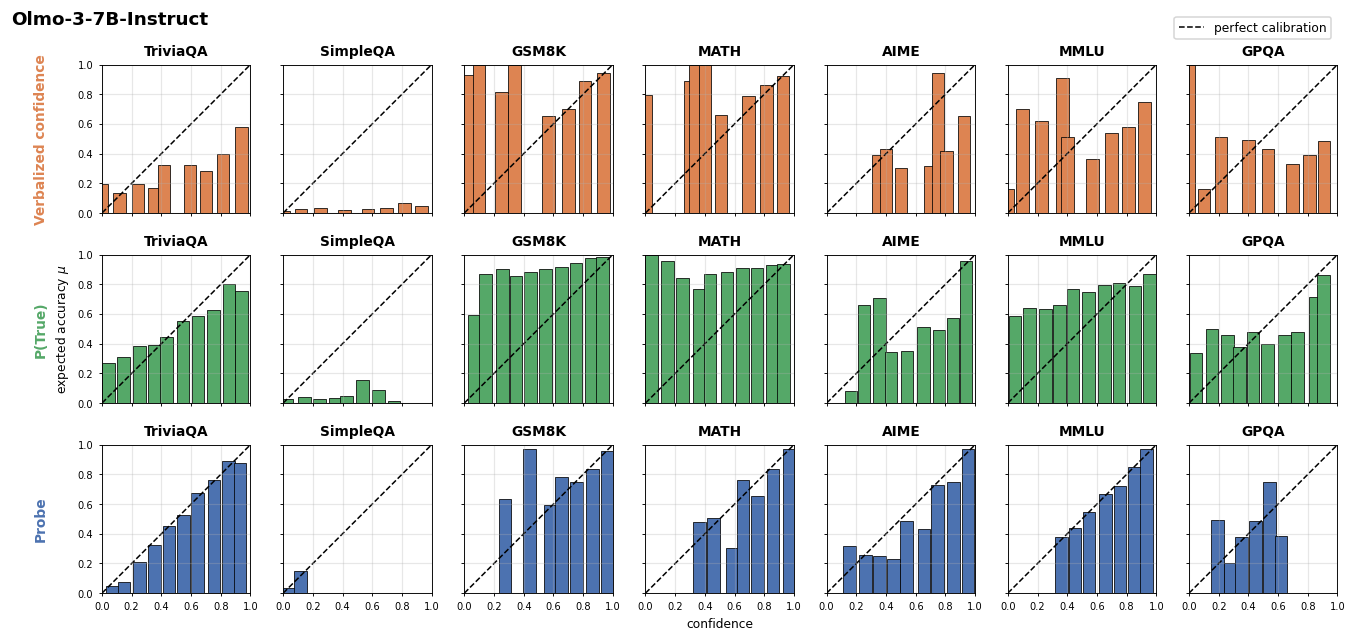

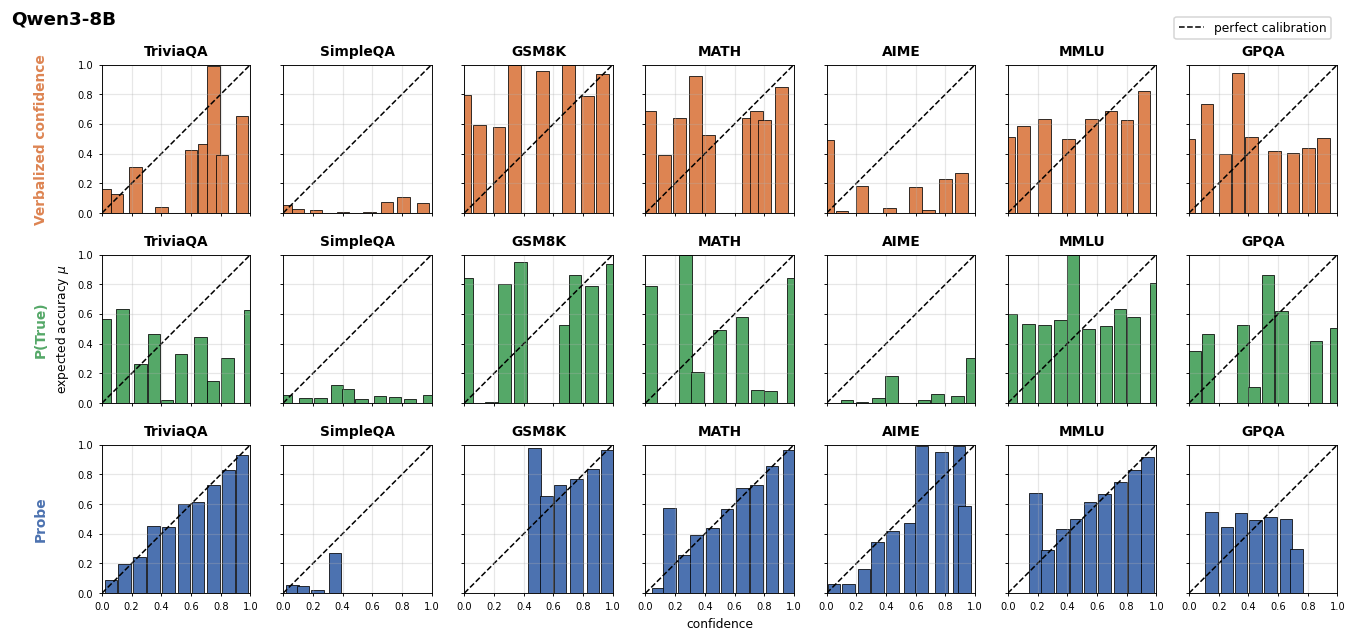

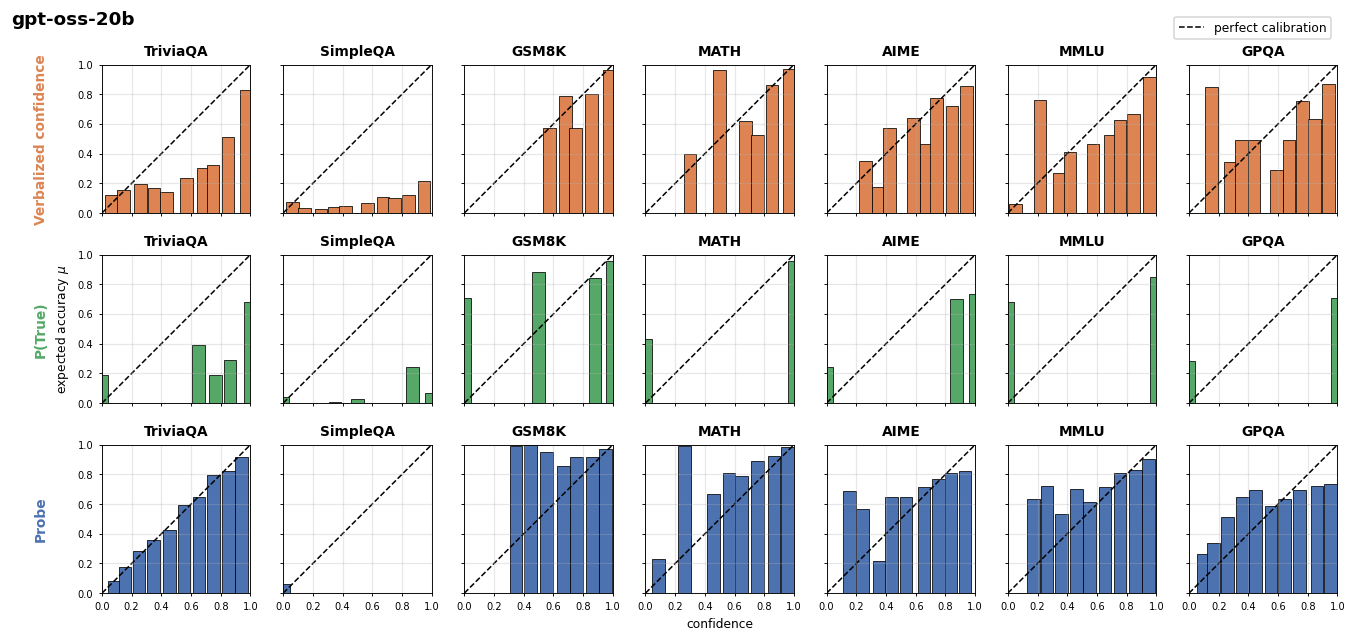

In [13]:
def model_page(cells: dict, model: Model):
    """One page per model: methods as rows, datasets as columns."""
    fig, axes = make_grid(len(PANEL_METHODS), len(DATASETS))

    for row, method in enumerate(PANEL_METHODS):
        for column, dataset in enumerate(DATASETS):
            ax = axes[row, column]
            cell = cells[(model.dir_name, dataset.label, method.key)]
            bins = bin_reliability(cell.confidence, cell.target)
            draw_reliability_bars(ax, bins, method.color)
            style_panel(ax)
            ax.set_title(dataset.label, fontsize=9, weight="semibold")
            ax.tick_params(labelbottom=row == len(PANEL_METHODS) - 1, labelleft=column == 0)
        draw_row_label(fig, axes[row], method.label, color=method.color)

    axes[-1][len(DATASETS) // 2].set_xlabel("confidence")
    axes[len(PANEL_METHODS) // 2][0].set_ylabel("expected accuracy $\\mu$")
    fig.text(0.01, 0.99, model.label, ha="left", va="top", fontsize=12, weight="bold")
    fig.legend(
        handles=[Line2D([], [], color="k", linestyle="--", linewidth=1.0, label="perfect calibration")],
        loc="upper right", bbox_to_anchor=(0.99, 0.99), frameon=True, fontsize=8,
    )
    return fig


pdf_path = FIG_DIR / "reliability_diagrams.pdf"
with PdfPages(pdf_path) as pdf:
    for model in MODELS:
        pdf.savefig(model_page(corrected, model))
print(f"wrote {pdf_path.relative_to(REPO)} ({len(MODELS)} pages)")

In [14]:
def soft_label_auroc(
    scores: np.ndarray,
    labels: np.ndarray,
    eps: float = 1e-12,
) -> float:
    """
    Fractional-label AUROC.

    Equivalent to rollout-level AUROC when labels[i] is the fraction
    of correct rollouts for query i and every query has the same
    number of rollouts.
    """
    s = np.asarray(scores, dtype=float).reshape(-1)
    y = np.asarray(labels, dtype=float).reshape(-1)

    if s.shape != y.shape:
        raise ValueError("scores and labels must have the same shape.")
    if not np.all(np.isfinite(s)) or not np.all(np.isfinite(y)):
        raise ValueError("scores and labels must be finite.")
    if np.any((y < 0.0) | (y > 1.0)):
        raise ValueError("labels must lie in [0, 1].")

    # Expected number of positive-i / negative-j rollout pairs.
    w = y[:, None] * (1.0 - y[None, :])

    diff = s[:, None] - s[None, :]
    pair_score = (diff > 0).astype(float) + 0.5 * (diff == 0)

    denominator = w.sum()
    if denominator < eps:
        return float("nan")

    return float((w * pair_score).sum() / denominator)


def emphasis_high(values: list[float]) -> list[str]:
    order = np.argsort(values, kind="mergesort")[::-1]
    marks = [""] * len(values)
    for rank, wrap in enumerate(("**", "*")):
        if rank < len(order) and not np.isnan(values[order[rank]]):
            marks[order[rank]] = wrap
    return marks


# (raw_key, iso_key or None, row label) — Probe has no isotonic
AUROC_ROWS = [
    ("verbalized", "verbalized_iso", "Verbalized"),
    ("ptrue", "ptrue_iso", "P(True)"),
    ("probe", None, "Probe"),
]
AUROC_KEYS = ["verbalized", "verbalized_iso", "ptrue", "ptrue_iso", "probe"]


def column_aurocs(cells: dict, model: str, dataset: str) -> dict[str, float]:
    return {
        k: soft_label_auroc(cells[(model, dataset, k)].confidence, cells[(model, dataset, k)].target)
        for k in AUROC_KEYS
    }


def fmt_auroc(v: float, mark: str) -> str:
    return f"{mark}{v:.4f}{mark}"


def soft_auroc_table(cells: dict) -> str:
    n = len(DATASETS)
    ds_hdr = "||" + "|".join(c for d in DATASETS for c in (d.label, "")).rstrip("|") + "|"
    subhdr = "|Model|Estimator|" + "|".join("Raw|+Iso" for _ in DATASETS) + "|"
    sep = "|---|---|" + "|".join("---:|---:" for _ in DATASETS) + "|"
    lines = [ds_hdr, subhdr, sep]

    for model in MODELS:
        col_vals, col_marks = [], []
        for d in DATASETS:
            vals = column_aurocs(cells, model.dir_name, d.label)
            col_vals.append(vals)
            col_marks.append(dict(zip(AUROC_KEYS, emphasis_high([vals[k] for k in AUROC_KEYS]))))

        for row, (raw_key, iso_key, label) in enumerate(AUROC_ROWS):
            mcol = f"**{model.label}**" if row == 0 else ""
            cells_out = []
            for c in range(n):
                v, m = col_vals[c], col_marks[c]
                cells_out.append(fmt_auroc(v[raw_key], m[raw_key]))
                cells_out.append("—" if iso_key is None else fmt_auroc(v[iso_key], m[iso_key]))
            lines.append(f"|{mcol}|{label}|" + "|".join(cells_out) + "|")
    return "\n".join(lines)


print(soft_auroc_table(corrected))

||TriviaQA||SimpleQA||GSM8K||MATH||AIME||MMLU||GPQA|
|Model|Estimator|Raw|+Iso|Raw|+Iso|Raw|+Iso|Raw|+Iso|Raw|+Iso|Raw|+Iso|Raw|+Iso|
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
|**Olmo-3-7B-Instruct**|Verbalized|0.6603|0.6574|0.5888|0.5849|0.5923|0.5846|0.5943|*0.5964*|*0.6602*|0.6417|0.6138|0.6134|*0.5612*|0.5502|
||P(True)|*0.6852*|0.6850|*0.6270*|0.6205|*0.6767*|0.6753|0.5892|0.5850|0.5419|0.5366|*0.6175*|0.6151|0.5175|0.5243|
||Probe|**0.8090**|—|**0.6891**|—|**0.7624**|—|**0.8463**|—|**0.7596**|—|**0.7279**|—|**0.6557**|—|
|**Qwen3-8B**|Verbalized|0.6324|0.6320|**0.5816**|*0.5809*|0.5311|0.5324|0.5950|0.5928|0.5970|0.6091|0.6286|0.6279|0.5304|0.5299|
||P(True)|0.7274|*0.7304*|0.5397|0.5324|0.7122|*0.7125*|0.7088|*0.7116*|0.7582|*0.7638*|*0.6955*|0.6935|**0.6377**|*0.6149*|
||Probe|**0.8158**|—|0.5040|—|**0.7713**|—|**0.8599**|—|**0.8301**|—|**0.7231**|—|0.4982|—|
|**gpt-oss-20b**|Verbalized|**0.8264**|*0.8262*|**0.7029**|*0.7010*|**0.7034**|*0.